In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
import json
import pickle
import os


def confidence_ellipse(val, cov, ax, n_std=1.0, facecolor='none', **kwargs):
    pearson = cov[0, 1]/np.sqrt(cov[0, 0] * cov[1, 1])
    # Using a special case to obtain the eigenvalues of this
    # two-dimensional dataset.
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2,
                      facecolor=facecolor, **kwargs)
    

    eig = np.linalg.eig(cov)
    
    # Calculating the standard deviation of x from

    # the squareroot of the variance and multiplying
    # with the given number of standard deviations.
    scale_x = np.sqrt(cov[0, 0]) * n_std
    mean_x = val[0]

    # calculating the standard deviation of y ...
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_y = val[1]

    transf = transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(mean_x, mean_y)

    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

# path = '/home/tguethle/Documents/spi/Master_Thesis/main_files/crab_19/'

# val = np.loadtxt(f'{path}fit_2003/crab_band_fit/fit_val.txt')
# cov = np.loadtxt(f'{path}fit_2003/crab_band_fit/fit_cov.txt')
# confidence_ellipse(val[:2], cov[:2, :2], ax, n_std=1, edgecolor=edgecolor, label=name, ls=linestyle, linewidth=1.5)

## cutoff pl. combine different datasets into one plot



In [3]:
path = '/home/tguethle/Documents/spi/Master_Thesis/main_files/crab_pp/'

config_files = [
    "test_config.json",
    "2008_cutoff_pl.json",
    "config_rev_727_1.json",
    "config_2014_1.json",
    "config_rev_1927_1.json"
]

# make on dictionary for all the data
configs = {}
for config_file in config_files:
    with open(f'{path}config/{config_file}', 'r') as f:
        current_config = json.load(f)
    configs.update(current_config)


folders, names, revolutions = [], [], []
for name, config_values in configs.items():
    if config_values["crab_model"] == "crab_cutoff_powerlaw":
        folders.append(f"{path}{config_values['data']['data_name']}/{name}")
        folders.append(f"{path}{config_values['data']['data_name']}/{name}_smf_combined")
        names.append(name + "_PySPI")
        names.append(f"{name}_spimodfit")
        revolutions.append(config_values["data"]["revolutions"][0])
        revolutions.append(config_values["data"]["revolutions"][0])


print(folders)
print(names)

for folder in folders:
    if not os.path.exists(folder):
        print(f"Folder {folder} does not exist.")
        
        revolutions.pop(folders.index(folder))
        names.pop(folders.index(folder))
        folders.pop(folders.index(folder))

['/home/tguethle/Documents/spi/Master_Thesis/main_files/crab_pp/test_data_2008/cutoff_powerlaw_fit', '/home/tguethle/Documents/spi/Master_Thesis/main_files/crab_pp/test_data_2008/cutoff_powerlaw_fit_smf_combined', '/home/tguethle/Documents/spi/Master_Thesis/main_files/crab_pp/data_rev_727/cutoff_powerlaw_fit_727', '/home/tguethle/Documents/spi/Master_Thesis/main_files/crab_pp/data_rev_727/cutoff_powerlaw_fit_727_smf_combined', '/home/tguethle/Documents/spi/Master_Thesis/main_files/crab_pp/data_2014_1461/cutoff_powerlaw_fit_2014', '/home/tguethle/Documents/spi/Master_Thesis/main_files/crab_pp/data_2014_1461/cutoff_powerlaw_fit_2014_smf_combined', '/home/tguethle/Documents/spi/Master_Thesis/main_files/crab_pp/data_rev_1927/cutoff_powerlaw_fit_1927', '/home/tguethle/Documents/spi/Master_Thesis/main_files/crab_pp/data_rev_1927/cutoff_powerlaw_fit_1927_smf_combined']
['cutoff_powerlaw_fit_PySPI', 'cutoff_powerlaw_fit_spimodfit', 'cutoff_powerlaw_fit_727_PySPI', 'cutoff_powerlaw_fit_727_spim

In [4]:
names

['cutoff_powerlaw_fit_PySPI',
 'cutoff_powerlaw_fit_spimodfit',
 'cutoff_powerlaw_fit_727_PySPI',
 'cutoff_powerlaw_fit_727_spimodfit',
 'cutoff_powerlaw_fit_2014_PySPI',
 'cutoff_powerlaw_fit_2014_spimodfit',
 'cutoff_powerlaw_fit_1927_PySPI',
 'cutoff_powerlaw_fit_1927_spimodfit']

In [5]:

# real_vals = [7.68e-4, -1.98, -2.23]
# real_cov = np.array([[(0.04e-4)**2, 0, 0],
#                     [0, (0.005)**2, 0],
#                     [0, 0, (0.03)**2]])
piv = 100

rev_to_IJD = {
    665: 3005,
    727: 3190,
    1461: 5386,
    1927: 6638
              }


std_devs = [
    5,
    5,
    5,
    5,
    5,
    5,
    5,
    5,
]



#color stands for dataset
edgecolors = [
    "C0",
    "C0",
    "C1",
    "C1",
    "C2",
    "C2",
    "C3",
    "C3"
]

# linestyl for spimodfit / pyspi
linestyles = [
    "solid",
    "dotted",
    "solid",
    "dotted",
    "solid",
    "dotted",
    "solid",
    "dotted",
]


(211.08232226507127, 1000.0)

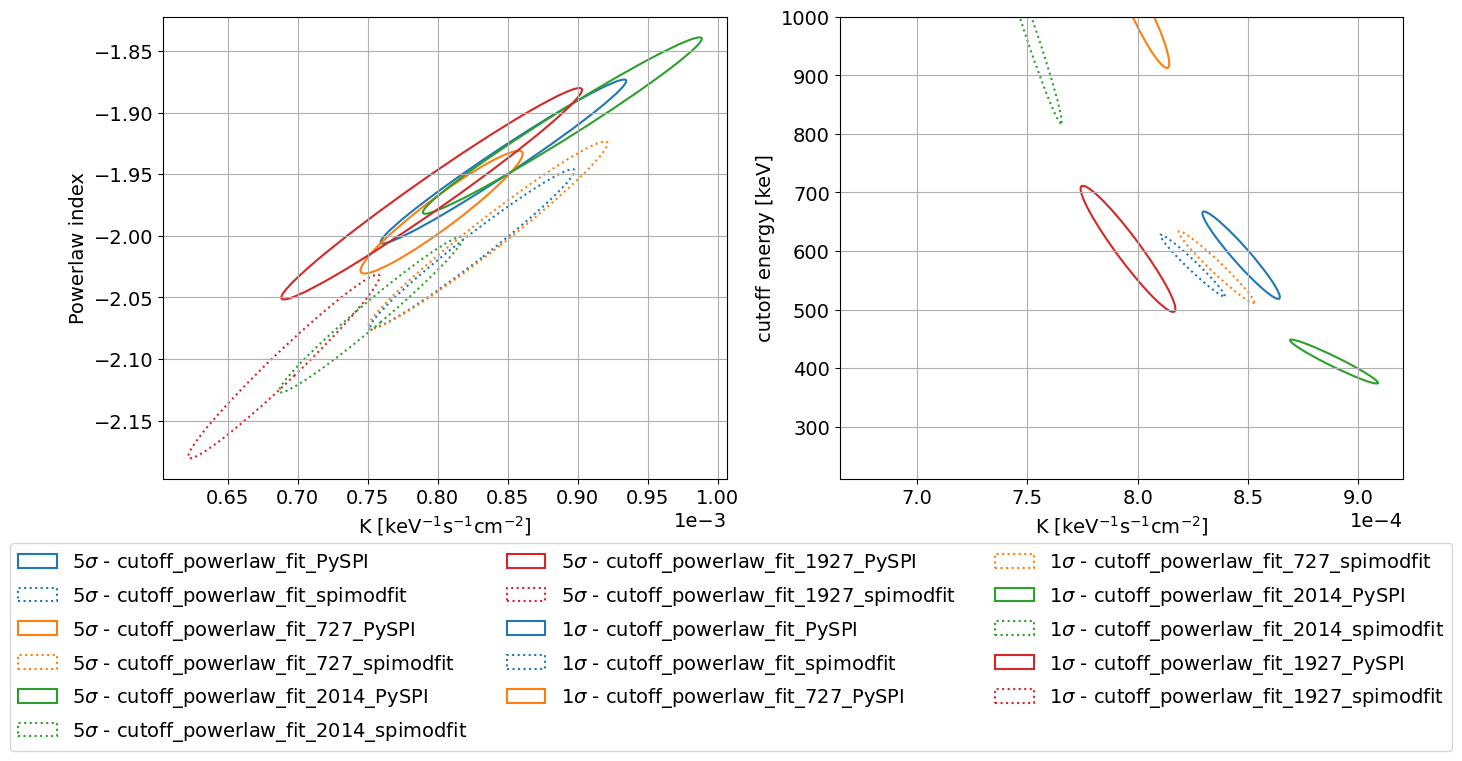

In [12]:
import math
%matplotlib inline
plt.rcParams.update({'font.size': 14})
fig, [ax, ax2] = plt.subplots(1, 2, figsize=(16, 6))



for folder, name, edgecolor, linestyle, std_dev in zip(folders, names, edgecolors, linestyles, std_devs):
    val = np.loadtxt(f"{folder}/fit_val.txt")
    cov = np.loadtxt(f"{folder}/fit_cov.txt")
    confidence_ellipse(val[:2], cov[:2, :2], ax, n_std=std_dev, edgecolor=edgecolor, label=f"{std_dev}$\sigma$ - {name}", ls=linestyle, linewidth=1.5)

    with open(f"{folder}/fit_val.txt", "r") as f:
        header = f.readlines()[0]

    # confidence_ellipse(val[0:3:2], cov[0:3:2, 0:3:2], ax2, n_std=std_dev, edgecolor=edgecolor, ls=linestyle, linewidth=1.5)
    confidence_ellipse(val[0:3:2], cov[0:3:2, 0:3:2], ax2, n_std=1, edgecolor=edgecolor, ls=linestyle, linewidth=1.5, label=f"1$\sigma$ - {name}")


ax.autoscale()
ax.grid()

ax2.autoscale()
ax2.grid()
# fig.legend(bbox_to_anchor=(0.9, 1), loc=2, borderaxespad=0.)
fig.legend(loc='lower center', bbox_to_anchor=(0.48, -0.36), ncol=3)
#plt.legend()
ax.set_xlabel("K [keV$^{-1}$s$^{-1}$cm$^{-2}$]")
ax.set_ylabel("Powerlaw index")

ax2.set_xlabel("K [keV$^{-1}$s$^{-1}$cm$^{-2}$]")
ax2.set_ylabel("cutoff energy [keV]")
ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax2.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

ax2.set_ylim(None, 1000)

# fig.suptitle('Data 2003', position=(0.5, 0.95))

In [13]:
fig.savefig(f"{path}plots/cutoff_pl_model_different_datasets.pdf", bbox_inches='tight')

In [68]:
names

['test_config_fit_PySPI',
 'test_config_fit_spimodfit',
 'band_fit_727_PySPI',
 'band_fit_727_spimodfit',
 'band_fit_2014_PySPI',
 'band_fit_1927_PySPI',
 'band_fit_1927_spimodfit']

## time series

3005
3005
3190
3190
5386
5386
6638
6638


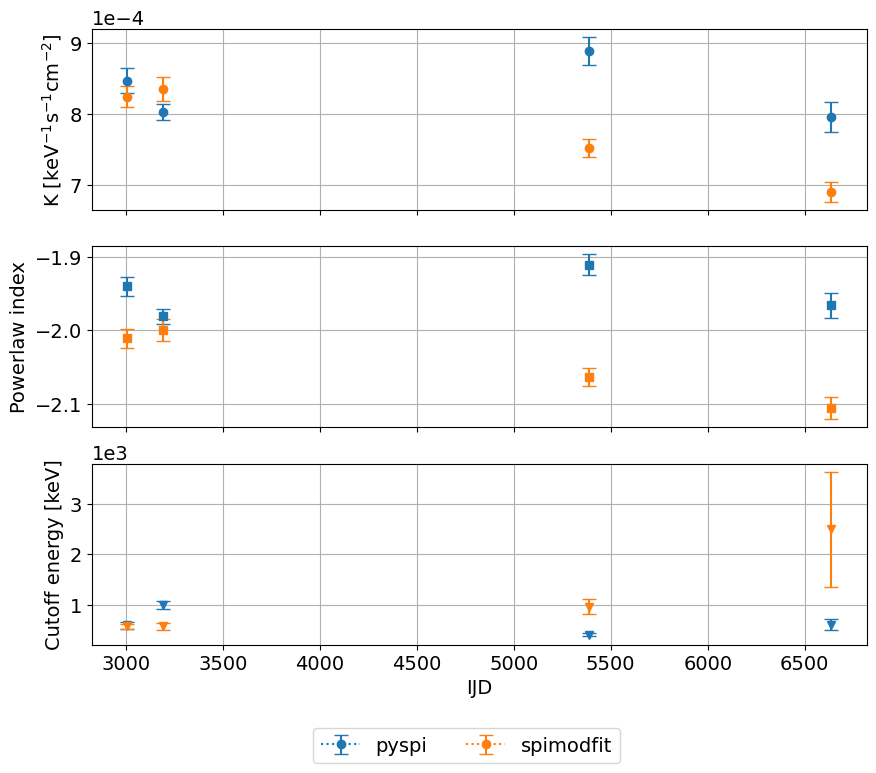

In [18]:
fig, axes = plt.subplots(3,1, figsize=(10, 8), sharex=True)

for ax in axes:
    ax.grid()
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

axes[0].set_ylabel("K [keV$^{-1}$s$^{-1}$cm$^{-2}$]")
axes[1].set_ylabel("Powerlaw index")
axes[2].set_ylabel("Cutoff energy [keV]")

axes[2].set_xlabel("IJD")

for folder, name, rev in zip(folders, names, revolutions):
    val = np.loadtxt(f"{folder}/fit_val.txt")
    cov = np.loadtxt(f"{folder}/fit_cov.txt")

    if "PySPI" in name:
        color = "C0"
    elif "spimodfit" in name:
        color = "C1"
    else:
        raise ValueError(f"Unknown name: {name}")

    ijd = rev_to_IJD[rev]
    print(ijd)
    
    axes[0].errorbar(ijd, val[0], yerr=np.sqrt(cov[0, 0]), fmt="o", color=color, label=name, ls=linestyle, capsize=5)
    axes[1].errorbar(ijd, val[1], yerr=np.sqrt(cov[1, 1]), fmt="s", color=color, label=name, ls=linestyle, capsize=5)
    axes[2].errorbar(ijd, val[2], yerr=np.sqrt(cov[2, 2]), fmt="v", color=color, label=name, ls=linestyle, capsize=5)

fig.legend(["pyspi", "spimodfit"], loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=2)
    

In [19]:
fig.savefig(f"{path}plots/cutoff_pl_model_time_evolution.pdf", bbox_inches='tight')